# O Impacto da Escala no Operador Densidade de Probabilidades em um Classificador Quântico

## Imports

In [1]:
import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold,train_test_split, KFold
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier, OutputCodeClassifier
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import check_array, check_is_fitted, check_X_y
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score, classification_report
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE
import ucimlrepo
from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

from qiskit.circuit import QuantumCircuit,Parameter, QuantumRegister, ClassicalRegister, Gate, Measure, ParameterVector
from qiskit_aer import Aer

import pandas as pd

from all_iqc import *

## Funções Locais

In [2]:
def get_stratified_kfold(k_folds, random_seed):
    return StratifiedKFold(n_splits=k_folds, random_state=random_seed, shuffle=True)

def get_U_operator_altered(params, N_features, N_qubits, N_qubits_tgt, iqcail=False, iqcndse=False, iqcangle=False):
    # ... (mantenha exatamente a mesma função que você forneceu)
    X = params[:N_features]
    vw = params[N_features:]
    #Montando os sigmas
    if iqcail==True:
        N_qubits_tgt=1
        X_new=np.array(X)
        w=np.array(vw)
        if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
            for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
                w=np.append(vw,0)
                X_new=np.append(X_new,0)
        
        sigmaE=np.diag(w)

    elif iqcndse==True:
        atx=np.array(X)
        atw=np.array(vw)
        if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
            for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
                atw=np.append(atw,0)
                atx=np.append(atx,0)
        X_new=np.matrix(atx)
        w=np.matrix(atw)
        # Ensure sigmaE is hermitian
        sigmaE = X_new.T @ w + (X_new.T @ w).T
    
    elif iqcangle==True:
        X_new=np.array(X)
        # Verifica se precisa ajustar sigmaE
        sigmaE = np.diag(vw)
        # Calcula o operador unitário U
        dim_circuit = 2 ** (N_qubits - 1)
        dim_sigmaE = sigmaE.shape[0]
        sigmaE = np.kron(np.eye(dim_circuit // dim_sigmaE), sigmaE)
    
    else:
        w = np.array(vw)
        X_new=np.array(X)
        if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
            for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
                w=np.append(w,0)
                X_new=np.append(X_new,0)
        sigmaE=np.diag(X_new)*w.T
    
    if N_qubits_tgt==1:
        sigma_q_params=[1,1,1,0]
        sigmaQ=get_weighted_sigmaQ(sigma_q_params,iqcpq=False)

    else:
        sigma_q_params=np.full(2**N_qubits_tgt,1)
        sigmaQ=get_weighted_sigmaQ(sigma_q_params,iqcpq=True)

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))
    return U

def normalize_data(X_train, X_val, dic_classifier_params):
    """
    Aplica a normalização dupla conforme especificado
    """
    normalize_axis = 0
    if "normalize_axis" in dic_classifier_params:
        normalize_axis = dic_classifier_params["normalize_axis"]

    # Normalização dupla para treino
    normalized_X_train = preprocessing.normalize(X_train, axis=normalize_axis)
    normalized_X_train = preprocessing.normalize(normalized_X_train, axis=1)
    
    # Normalização dupla para validação
    normalized_X_val = preprocessing.normalize(X_val, axis=normalize_axis)
    normalized_X_val = preprocessing.normalize(normalized_X_val, axis=1)
    
    return normalized_X_train, normalized_X_val

def get_rho_11_probability(params, N_features, N_qubits, N_qubits_tgt, qubits, N_layers, y_true):
    """
    Calcula ρ'₁₁ - probabilidade do elemento pertencer à classe y_true
    """
    qreg = QuantumRegister(N_qubits, 'q')
    qc = QuantumCircuit(qreg)
    
    # Reconstrói o circuito de embedding
    qc.h(0)
    rx_params = params[:N_features]
    
    for l in range(N_layers):
        for idx, qubit in enumerate(range(1, N_qubits)):
            qc.rx(rx_params[idx], qreg[qubit])
        for i in range(1, N_qubits - 1):
            qc.cx(qreg[i], qreg[i + 1])
        qc.barrier()
    
    # Aplica o operador unitário
    class IQC_Angle_UGate(Gate):
        def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
            super().__init__(name, num_qubits, params)
            self.N_features = N_features
            self.N_qubits_tgt = N_qubits_tgt
            
        def _define(self):
            q = QuantumRegister(self.num_qubits, 'q')
            qc = QuantumCircuit(q)
            param_values = [0] * len(self.params)
            U = get_U_operator_altered(param_values, N_features=self.N_features, 
                                     N_qubits=self.num_qubits, N_qubits_tgt=1, iqcangle=True)
            qc.unitary(U, range(self.num_qubits))
            self.definition = qc
            
        def validate_parameter(self, parameter):
            return parameter

    unitary_gate = IQC_Angle_UGate(f'U_IQC_Angle', N_qubits, params, N_features, N_qubits_tgt)
    
    # Calcula a matriz densidade
    p = DensityMatrix(qc)
    p_out = p.evolve(unitary_gate)
    p_cog_new = partial_trace(p_out, qubits[1:]).data
    
    # Retorna ρ'₁₁ se y_true=1, ou ρ'₀₀ se y_true=0
    if y_true == 1:
        return np.real(p_cog_new[1, 1])
    else:
        return np.real(p_cog_new[0, 0])

def executaclassificador(N_features, N_qubits, N_qubits_tgt, qubits, params, N_layers=2):
    """
    Versão modificada que retorna tanto a classificação quanto as probabilidades
    """
    qreg = QuantumRegister(N_qubits, 'q')
    creg = ClassicalRegister(N_qubits_tgt)
    qc = QuantumCircuit(qreg, creg)     

    qc.h(0)
    rx_params = params[:N_features]

    for l in range(N_layers):
        for idx, qubit in enumerate(range(1, N_qubits)):
            qc.rx(rx_params[idx], qreg[qubit])
        for i in range(1, N_qubits - 1):
            qc.cx(qreg[i], qreg[i + 1])
        qc.barrier()
    
    class IQC_Angle_UGate(Gate):
        def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
            super().__init__(name, num_qubits, params)
            self.N_features = N_features
            self.N_qubits_tgt = N_qubits_tgt
            
        def _define(self):
            q = QuantumRegister(self.num_qubits, 'q')
            qc = QuantumCircuit(q)
            param_values = [0] * len(self.params)
            U = get_U_operator_altered(param_values, N_features=self.N_features, 
                                     N_qubits=self.num_qubits, N_qubits_tgt=1, iqcangle=True)
            qc.unitary(U, range(self.num_qubits))
            self.definition = qc
            
        def validate_parameter(self, parameter):
            return parameter

    unitary_gate = IQC_Angle_UGate(f'U_IQC_Angle', N_qubits, params, N_features, N_qubits_tgt)
    
    """param_binding = {p: np.pi * rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)"""
    
    p = DensityMatrix(qc)
    p_out = p.evolve(unitary_gate)
    p_cog_new = partial_trace(p_out, qubits[1:]).data
    
    p_00 = np.real(p_cog_new[0, 0])
    p_11 = np.real(p_cog_new[1, 1])
    
    # Classificação
    z = 0 if p_00 >= p_11 else 1
    
    return p_cog_new, z

def executaiqc(vector_x,
               vector_ws,
               normalize_x=False,
               normalize_w=False,
               dic_classifier_params={},
               N_qubits=None,
               N_qubits_tgt=None):
    # IQC
    
    """
        Applies the a modified version of IQC classifier using only the math behind the Quantum Classifier described in Interactive Quantum Classifier Inspired by Quantum Open System Theory article. 
        
        It differs from the original IQC by adding a new component to Sigma Q: sigmaH, which corresponds to a Haddamard's gate. Another difference is that we load the input in the environment instead of having a combination of weights and inputs in sigmaE.

        After doing so, it gets the result of Equation #20 and returns Z as the predicted class and the probability of being the class 1.
        
        Works only for binary classifications, therefore, if the probability of class 0 is needed, it can be 1 - probability of being class 1.

        There are a few possible keys for the dic_classifier_params:
        - sigma_q_params (array) = weights used for calculating sigma_q
        - use_polar_coordinates_on_sigma_q (boolean) = whether to calculate sigma_q using polar coordinates or weighted sum
        - load_inputvector_env_state (boolean) = whether to load input vector on the environment state (True) or on sigma_e (False)
        - operation_for_sigma_e (string) = which operation will be used to combine weights and X for load_inputvector_env_state = False. For now, only "sum" and "mul" are available.
        - calculate_negativity (boolean) = enables the negativity calculation. Check https://en.wikipedia.org/wiki/Negativity_(quantum_mechanics). Uses Toqito implementation: https://toqito.readthedocs.io/en/latest/_autosummary/toqito.state_props.negativity.html
        - ending_hadamard_gate (int) =  adds a Hadamard gate after the U operator
        - use_exponential_on_input (boolean) = does the Euler exponential on the input data after normalizing (if applied)

        To have the original IQC Classifier, you can have:
        normalize_x = False
        normalize_w = False
        dic_classifier_params["load_inputvector_env_state"] = False
        dic_classifier_params["sigma_q_params"] = [1, 1, 1, 0]

        returns (z, p_cog_new_11_2, output_dict)

        output_dict contains:
        - U_operators = list of used U_operators
        - negativity = negativity associated with that entry
        - entropy = entropy associated with that entry
    """
    
    N = len(vector_x)

    if "sigma_q_params" in dic_classifier_params:
        sigma_q_params = dic_classifier_params["sigma_q_params"]
    if "use_polar_coordinates_on_sigma_q" in dic_classifier_params:
        use_polar_coordinates_on_sigma_q = dic_classifier_params["use_polar_coordinates_on_sigma_q"]
    
    
    if use_polar_coordinates_on_sigma_q:
        # Eq #16, but using polar coordinates so |sigmaQ| gets to be 1
        sigmaQ = get_sigmaQ_from_polar_coord(sigma_q_params)
    else:
        # Eq #16
        sigmaQ = get_weighted_sigmaQ(sigma_q_params)

    # We want to have multiple environments, thus we need to have a list of weights for each of them
    if not(isinstance(vector_ws, (list, np.ndarray)) and all(isinstance(item, (list, np.ndarray)) for item in vector_ws)):
        vector_ws = np.array(vector_ws, dtype=complex)
    
    # Eq 25
    p_env = np.ones((N,1))/np.sqrt(N)
    p_env = get_p(p_env)

    # Our first p_cog will be the original one, but will change overtime
    p_cog = np.ones((2,1)) / np.sqrt(2) 
    # Eq #18
    p_cog = get_p(p_cog)

    # We'll update the p_cog for every env we have
    p_cog_new = p_cog
    U_operators = []
    for vector_w in vector_ws:
        if normalize_w:
            vector_w = normalize(vector_w)
        
        # Equivalent to Eq #15
        sigmaE = get_sigmaE(vector_x, vector_w, dic_classifier_params)

        U_operator = get_U_operator(sigmaQ, sigmaE)
        U_operators.append(U_operator)

        # Extracting p_cog and p_env kron
        p_cog_env = np.kron(p_cog_new, p_env)

        # First part of Equation #20 in the Article
        p_out = np.array(U_operator * p_cog_env * U_operator.getH())
        
        # Second part of Equation #20 in the Article
        # For multiple environemnts, this will be our new p_cog
        p_cog_new = np.trace(p_out.reshape([2,N,2,N]), axis1=1, axis2=3)
        
    # As the result is a diagonal matrix, the probability of being class 0 will be on position 0,0
    p_cog_new_00_2 = p_cog_new[0,0]

    # ... and the probability of being class 1 will be on position 1,1
    p_cog_new_11_2 = p_cog_new[1,1]
    if (p_cog_new_00_2 >= p_cog_new_11_2):
        z = 0
    else:
        z = 1


    output_dict = {}
    output_dict["U_operators"] = U_operators
    
    if "calculate_negativity" in dic_classifier_params and dic_classifier_params["calculate_negativity"]:
        output_dict["negativity"] = get_negativity(p_out, [2, N])

        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/IQC-studies/experiments/Iris/Entanglement/in_out/evolution_calc.txt', 'a') as file:
        #     string_to_write = "\nvector_x = " + generate_output_matrix_string(vector_x) + ";\n"\
        #                     + "vector_w = " + generate_output_matrix_string(vector_w) + ";\n"\
        #                     + "p_cog_new = " + generate_output_matrix_string(p_cog_new) + ";\n"
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")

        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/IQC-studies/experiments/Iris/Entanglement/in_out/ins_and_outs.txt', 'a') as file:
        #     string_to_write = "\nvector_x = " + generate_output_matrix_string(vector_x) + ";\n"\
        #                     + "vector_w = " + generate_output_matrix_string(vector_w) + ";\n"\
        #                     + "sigmaQ = " + generate_output_matrix_string(sigmaQ) + ";\n"\
        #                     + "sigmaE = " + generate_output_matrix_string(sigmaE) + ";\n"\
        #                     + "p_cog = " + generate_output_matrix_string(p_cog) + ";\n"\
        #                     + "p_env = " + generate_output_matrix_string(p_env) + ";\n"\
        #                     + "p_cog_env = " + generate_output_matrix_string(p_cog_env) + ";\n"\
        #                     + "p_out = " + generate_output_matrix_string(p_out) + ";\n"\
        #                     + "p_cog_new = " + generate_output_matrix_string(p_cog_new) + ";\n"
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")

        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/IQC-studies/experiments/Iris/Entanglement/in_out/negativity.txt', 'a') as file:
        #     string_to_write = "\np_out = " + generate_output_matrix_string(p_out) + ";\n\n - Negativity = " + str(output_dict["negativity"])
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")

    if "calculate_entropy" in dic_classifier_params and dic_classifier_params["calculate_entropy"]:
        output_dict["entropy"] = get_entropy(p_out)
        
        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/IQC-studies/experiments/Iris/Entanglement/in_out/entropy.txt', 'a') as file:
        #     string_to_write = "\np_out = " + generate_output_matrix_string(p_out) + ";\n\n -Entropy = " + str(output_dict["entropy"])
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")
     
    return z, p_cog_new, output_dict

def update_weights(weights, learning_rate, error, rho_11, x_i):
    """
    Implementa a equação de atualização:
    w_{i,j+1} = w_j - η(z_k - y_k)(1 - ρ'₁₁)x_i
    """
    new_weights = weights.copy()
    for i in range(len(weights)):
        update_term = learning_rate * error * (1 - rho_11) * x_i[i]
        new_weights[i] = weights[i] - update_term
    return new_weights

def encode_labels(y):
    """
    Converte labels string para numéricas se necessário
    """
    if isinstance(y[0,0], str):
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        print(f"Labels convertidas: {np.unique(y)} -> {np.unique(y_encoded)}")
        return y_encoded, le
    else:
        return y, None

def train_single_epoch(X_train_normalized, y_train, weights, learning_rate, dic_classifier_params):
    """
    Executa uma única época de treinamento
    """
    train_correct = 0
    total_error = 0
    
    for k in range(len(X_train_normalized)):
        # Combina features normalizadas e pesos
        current_params = list(X_train_normalized[k]) + list(weights)
        
        # Obtém classificação e probabilidades
        z_k, p_00, p_11 = circuit_angle_embedding_with_probability(
            N_features=N_FEATURES,
            N_qubits=dic_classifier_params["N_qubits"],
            N_qubits_tgt=1,
            qubits=dic_classifier_params["qubits"],
            params=current_params,
            N_layers=dic_classifier_params["N_layers"]
        )
        
        # Calcula ρ'₁₁ para a classe verdadeira
        rho_11 = get_rho_11_probability(
            params=current_params,
            N_features=N_FEATURES,
            N_qubits=dic_classifier_params["N_qubits"],
            N_qubits_tgt=1,
            qubits=dic_classifier_params["qubits"],
            N_layers=dic_classifier_params["N_layers"],
            y_true=y_train[k]
        )
        
        # Calcula erro e atualiza pesos - CONVERSÃO EXPLÍCITA PARA INT
        error = z_k - int(y_train[k])  # Garante que ambos sejam inteiros
        total_error += abs(error)
        
        if z_k == y_train[k]:
            train_correct += 1
        
        # Atualização dos pesos usando a equação fornecida
        weights = update_weights(weights, learning_rate, error, rho_11, X_train_normalized[k])
    
    train_accuracy = train_correct / len(X_train_normalized)
    return weights, train_accuracy, total_error


In [ ]:
def get_stratified_kfold(k_folds, random_seed):
    return StratifiedKFold(n_splits=k_folds, random_state=random_seed, shuffle=True)

def get_U_operator_altered(params, N_features, N_qubits, N_qubits_tgt, iqcail=False, iqcndse=False, iqcangle=False):
    # ... (mantenha exatamente a mesma função que você forneceu)
    X = params[:N_features]
    vw = params[N_features:]
    #Montando os sigmas
    if iqcail==True:
        N_qubits_tgt=1
        X_new=np.array(X)
        w=np.array(vw)
        if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
            for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
                w=np.append(vw,0)
                X_new=np.append(X_new,0)
        
        sigmaE=np.diag(w)

    elif iqcndse==True:
        atx=np.array(X)
        atw=np.array(vw)
        if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
            for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
                atw=np.append(atw,0)
                atx=np.append(atx,0)
        X_new=np.matrix(atx)
        w=np.matrix(atw)
        # Ensure sigmaE is hermitian
        sigmaE = X_new.T @ w + (X_new.T @ w).T
    
    elif iqcangle==True:
        X_new=np.array(X)
        # Verifica se precisa ajustar sigmaE
        sigmaE = np.diag(vw)
        # Calcula o operador unitário U
        dim_circuit = 2 ** (N_qubits - 1)
        dim_sigmaE = sigmaE.shape[0]
        sigmaE = np.kron(np.eye(dim_circuit // dim_sigmaE), sigmaE)
    
    else:
        w = np.array(vw)
        X_new=np.array(X)
        if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
            for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
                w=np.append(w,0)
                X_new=np.append(X_new,0)
        sigmaE=np.diag(X_new)*w.T
    
    if N_qubits_tgt==1:
        sigma_q_params=[1,1,1,0]
        sigmaQ=get_weighted_sigmaQ(sigma_q_params,iqcpq=False)

    else:
        sigma_q_params=np.full(2**N_qubits_tgt,1)
        sigmaQ=get_weighted_sigmaQ(sigma_q_params,iqcpq=True)

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))
    return U

def normalize_data(X_train, X_val, dic_classifier_params):
    """
    Aplica a normalização dupla conforme especificado
    """
    normalize_axis = 0
    if "normalize_axis" in dic_classifier_params:
        normalize_axis = dic_classifier_params["normalize_axis"]

    # Normalização dupla para treino
    normalized_X_train = preprocessing.normalize(X_train, axis=normalize_axis)
    normalized_X_train = preprocessing.normalize(normalized_X_train, axis=1)
    
    # Normalização dupla para validação
    normalized_X_val = preprocessing.normalize(X_val, axis=normalize_axis)
    normalized_X_val = preprocessing.normalize(normalized_X_val, axis=1)
    
    return normalized_X_train, normalized_X_val

def get_rho_11_probability(params, N_features, N_qubits, N_qubits_tgt, qubits, N_layers, y_true):
    """
    Calcula ρ'₁₁ - probabilidade do elemento pertencer à classe y_true
    """
    qreg = QuantumRegister(N_qubits, 'q')
    qc = QuantumCircuit(qreg)
    
    # Reconstrói o circuito de embedding
    qc.h(0)
    rx_params = params[:N_features]
    
    for l in range(N_layers):
        for idx, qubit in enumerate(range(1, N_qubits)):
            qc.rx(rx_params[idx], qreg[qubit])
        for i in range(1, N_qubits - 1):
            qc.cx(qreg[i], qreg[i + 1])
        qc.barrier()
    
    # Aplica o operador unitário
    class IQC_Angle_UGate(Gate):
        def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
            super().__init__(name, num_qubits, params)
            self.N_features = N_features
            self.N_qubits_tgt = N_qubits_tgt
            
        def _define(self):
            q = QuantumRegister(self.num_qubits, 'q')
            qc = QuantumCircuit(q)
            param_values = [0] * len(self.params)
            U = get_U_operator_altered(param_values, N_features=self.N_features, 
                                     N_qubits=self.num_qubits, N_qubits_tgt=1, iqcangle=True)
            qc.unitary(U, range(self.num_qubits))
            self.definition = qc
            
        def validate_parameter(self, parameter):
            return parameter

    unitary_gate = IQC_Angle_UGate(f'U_IQC_Angle', N_qubits, params, N_features, N_qubits_tgt)
    
    # Calcula a matriz densidade
    p = DensityMatrix(qc)
    p_out = p.evolve(unitary_gate)
    p_cog_new = partial_trace(p_out, qubits[1:]).data
    
    # Retorna ρ'₁₁ se y_true=1, ou ρ'₀₀ se y_true=0
    if y_true == 1:
        return np.real(p_cog_new[1, 1])
    else:
        return np.real(p_cog_new[0, 0])

def circuit_angle_embedding_with_probability(N_features, N_qubits, N_qubits_tgt, qubits, params, N_layers=2):
    """
    Versão modificada que retorna tanto a classificação quanto as probabilidades
    """
    qreg = QuantumRegister(N_qubits, 'q')
    creg = ClassicalRegister(N_qubits_tgt)
    qc = QuantumCircuit(qreg, creg)     

    qc.h(0)
    rx_params = params[:N_features]

    for l in range(N_layers):
        for idx, qubit in enumerate(range(1, N_qubits)):
            qc.rx(rx_params[idx], qreg[qubit])
        for i in range(1, N_qubits - 1):
            qc.cx(qreg[i], qreg[i + 1])
        qc.barrier()
    
    class IQC_Angle_UGate(Gate):
        def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
            super().__init__(name, num_qubits, params)
            self.N_features = N_features
            self.N_qubits_tgt = N_qubits_tgt
            
        def _define(self):
            q = QuantumRegister(self.num_qubits, 'q')
            qc = QuantumCircuit(q)
            param_values = [0] * len(self.params)
            U = get_U_operator_altered(param_values, N_features=self.N_features, 
                                     N_qubits=self.num_qubits, N_qubits_tgt=1, iqcangle=True)
            qc.unitary(U, range(self.num_qubits))
            self.definition = qc
            
        def validate_parameter(self, parameter):
            return parameter

    unitary_gate = IQC_Angle_UGate(f'U_IQC_Angle', N_qubits, params, N_features, N_qubits_tgt)
    
    """param_binding = {p: np.pi * rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)"""
    
    p = DensityMatrix(qc)
    p_out = p.evolve(unitary_gate)
    p_cog_new = partial_trace(p_out, qubits[1:]).data
    
    p_00 = np.real(p_cog_new[0, 0])
    p_11 = np.real(p_cog_new[1, 1])
    
    # Classificação
    z = 0 if p_00 >= p_11 else 1
    
    return z, p_00, p_11

def update_weights(weights, learning_rate, error, rho_11, x_i):
    """
    Implementa a equação de atualização:
    w_{i,j+1} = w_j - η(z_k - y_k)(1 - ρ'₁₁)x_i
    """
    new_weights = weights.copy()
    for i in range(len(weights)):
        update_term = learning_rate * error * (1 - rho_11) * x_i[i]
        new_weights[i] = weights[i] - update_term
    return new_weights

def encode_labels(y):
    """
    Converte labels string para numéricas se necessário
    """
    if isinstance(y[0,0], str):
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        print(f"Labels convertidas: {np.unique(y)} -> {np.unique(y_encoded)}")
        return y_encoded, le
    else:
        return y, None

def train_single_epoch(X_train_normalized, y_train, weights, learning_rate, dic_classifier_params):
    """
    Executa uma única época de treinamento
    """
    train_correct = 0
    total_error = 0
    
    for k in range(len(X_train_normalized)):
        # Combina features normalizadas e pesos
        current_params = list(X_train_normalized[k]) + list(weights)
        
        # Obtém classificação e probabilidades
        z_k, p_00, p_11 = circuit_angle_embedding_with_probability(
            N_features=N_FEATURES,
            N_qubits=dic_classifier_params["N_qubits"],
            N_qubits_tgt=1,
            qubits=dic_classifier_params["qubits"],
            params=current_params,
            N_layers=dic_classifier_params["N_layers"]
        )
        
        # Calcula ρ'₁₁ para a classe verdadeira
        rho_11 = get_rho_11_probability(
            params=current_params,
            N_features=N_FEATURES,
            N_qubits=dic_classifier_params["N_qubits"],
            N_qubits_tgt=1,
            qubits=dic_classifier_params["qubits"],
            N_layers=dic_classifier_params["N_layers"],
            y_true=y_train[k]
        )
        
        # Calcula erro e atualiza pesos - CONVERSÃO EXPLÍCITA PARA INT
        error = z_k - int(y_train[k])  # Garante que ambos sejam inteiros
        total_error += abs(error)
        
        if z_k == y_train[k]:
            train_correct += 1
        
        # Atualização dos pesos usando a equação fornecida
        weights = update_weights(weights, learning_rate, error, rho_11, X_train_normalized[k])
    
    train_accuracy = train_correct / len(X_train_normalized)
    return weights, train_accuracy, total_error

def print_and_save_weights(weights, model, database, print_all=False):
    """
        Prints and saves the best weights used in the training.
        Weights are saved in a CSV file with the current date.
    """
    if print_all:
        print("Weights:", weights)
    
    # Preparação do DataFrame para salvar
    data_to_save = {
        'Weights': weights
    }
    
    weights_df = pd.DataFrame(data_to_save)
    
    # Nome do arquivo com data atual
    current_date = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename = f"{model}_{database}_weights_{current_date}.csv"
    
    # Salvando em CSV
    weights_df.to_csv(filename, index=False)
    print(f"\nWeights saved in: {filename}")

def print_and_save_negativity(negativities, model, database, print_all=False):
    """
        Prints and saves the mean negativity per class obtained in the training.
        Negativity is saved in a CSV file with the current date.
    """
    # Filtra listas vazias
    negativities = [neg for neg in negativities if len(neg) > 0]
    
    if len(negativities) == 0:
        print("No negativity data to save.")
        return
    
    negativities_metrics = {
        f"Negativity_Class_{i}": {
            "Mean": np.mean(values),
            "Std_Error": np.std(values, ddof=1) / np.sqrt(len(values))
        }
        for i, values in enumerate(negativities)
    }
    
    if print_all:
        print("Negativity:", negativities)
    
    # Preparação do DataFrame para salvar
    for i, metrics in negativities_metrics.items():
        print(f"{i} - AVG: {metrics['Mean']:.4f} ± {metrics['Std_Error']:.4f}")
    
    # Adiciona as negatividades por classe ao DataFrame
    data_to_save = {}
    for i, values in enumerate(negativities):
        data_to_save[f"Negativity_Class_{i}"] = values

    negativity_df = pd.DataFrame(data_to_save)
    
    # Nome do arquivo com data atual
    current_date = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename = f"{model}_{database}_negativity_{current_date}.csv"
    
    # Salvando em CSV
    negativity_df.to_csv(filename, index=False)
    print(f"\nNegativity saved in: {filename}")

def print_and_save_metrics(scores, f1scores, n_times_kfold, k_times_fold, model, database, print_all=False):
    """
    Prints and saves accuracy and F1-score metrics
    """
    # Cálculo das métricas básicas
    best_score = np.max(scores)
    best_f1 = np.max(f1scores)
    avg_score = np.mean(scores)
    avg_f1 = np.mean(f1scores)
    std_err_score = np.std(scores, ddof=1) / np.sqrt(len(scores))
    std_err_f1 = np.std(f1scores, ddof=1) / np.sqrt(len(f1scores))

    # Impressão dos resultados
    if print_all:
        print("Accuracy:", scores)
        print("F1-Scores:", f1scores)

    print(f"\nMetrics for {n_times_kfold} times {k_times_fold} folds:")
    print(f"Best Accuracy: {best_score:.4f}")
    print(f"Best F1-Score: {best_f1:.4f}")
    print(f"AVG Accuracy: {avg_score:.4f} ± {std_err_score:.4f}")
    print(f"AVG F1-Score: {avg_f1:.4f} ± {std_err_f1:.4f}")
    
    # Preparação do DataFrame para salvar
    data_to_save = {
        'Accuracy': scores,
        'F1_Scores': f1scores
    }

    metrics_df = pd.DataFrame(data_to_save)
    
    # Nome do arquivo com data atual
    current_date = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename = f"{model}_{database}_metrics_results_{current_date}.csv"
    
    # Salvando em CSV
    metrics_df.to_csv(filename, index=False)
    print(f"\nMetrics saved in: {filename}")

"""def execute_30x10_fold_cross_validation(
    X, 
    y, 
    learning_rate=0.01,
    epochs=100,
    dic_classifier_params={},
    print_each_fold_metric=False,
    print_avg_metric=True,
    model_name="IQC_Classifier",
    database_name="Dataset"
):
    '''
    Executa validação cruzada 30x10-fold unificada com todas as funcionalidades
    '''
    # CONVERSÃO DAS LABELS - CORREÇÃO DO ERRO
    y_encoded, label_encoder = encode_labels(y)
    
    all_results = []
    global_scores = []
    global_f1scores = []
    global_negativities = [[]]
    global_entropies = [[]]
    all_weights = []  # Para armazenar todos os pesos
    
    for repetition in range(30):  # 30 repetições
        print(f"\n=== Repetição {repetition + 1}/30 ===")
        
        # Embaralha os dados para cada repetição
        shuffle_idx = rng.permutation(len(X))
        X_shuffled = X[shuffle_idx]
        y_shuffled = y_encoded[shuffle_idx]  # Usa as labels codificadas
        
        # Stratified K-Fold
        skf = get_stratified_kfold(k_folds=10, random_seed=repetition)
        repetition_scores = []
        repetition_f1scores = []
        repetition_weights = []
        
        for fold, (train_index, test_index) in enumerate(skf.split(X_shuffled, y_shuffled)):
            print(f"  Fold {fold + 1}/10")
            
            X_train, X_test = X_shuffled[train_index], X_shuffled[test_index]
            y_train, y_test = y_shuffled[train_index], y_shuffled[test_index]
            
            # Aplica normalização
            X_train_normalized, X_test_normalized = normalize_data(
                X_train, X_test, dic_classifier_params
            )
            
            # Verifica distribuição das classes
            train_class_dist = np.bincount(y_train)
            test_class_dist = np.bincount(y_test)
            print(f"    Distribuição - Treino: {train_class_dist}, Teste: {test_class_dist}")
            
            # Inicializa pesos
            weights = rng.random(N_FEATURES) * 0.01
            fold_train_accuracies = []
            fold_val_accuracies = []
            weight_history = [weights.copy()]
            
            # Treinamento com múltiplas épocas
            for epoch in range(epochs):
                weights, train_accuracy, total_error = train_single_epoch(
                    X_train_normalized, y_train, weights, learning_rate, dic_classifier_params
                )
                
                weight_history.append(weights.copy())
                fold_train_accuracies.append(train_accuracy)
                
                # Validação no conjunto de teste
                val_correct = 0
                for k in range(len(X_test_normalized)):
                    test_params = list(X_test_normalized[k]) + list(weights)
                    z_k, _, _ = circuit_angle_embedding_with_probability(
                        N_features=N_FEATURES,
                        N_qubits=dic_classifier_params["N_qubits"],
                        N_qubits_tgt=1,
                        qubits=dic_classifier_params["qubits"],
                        params=test_params,
                        N_layers=dic_classifier_params["N_layers"]
                    )
                    if z_k == y_test[k]:
                        val_correct += 1
                
                val_accuracy = val_correct / len(X_test_normalized)
                fold_val_accuracies.append(val_accuracy)
                
                if epoch % 20 == 0:  # Print a cada 20 épocas
                    print(f"    Época {epoch+1}: Treino={train_accuracy:.4f}, Validação={val_accuracy:.4f}")
            
            # Avaliação final do fold
            final_val_correct = 0
            final_predictions = []
            for k in range(len(X_test_normalized)):
                test_params = list(X_test_normalized[k]) + list(weights)
                z_k, _, _ = circuit_angle_embedding_with_probability(
                    N_features=N_FEATURES,
                    N_qubits=dic_classifier_params["N_qubits"],
                    N_qubits_tgt=1,
                    qubits=dic_classifier_params["qubits"],
                    params=test_params,
                    N_layers=dic_classifier_params["N_layers"]
                )
                final_predictions.append(z_k)
                if z_k == y_test[k]:
                    final_val_correct += 1
            
            final_accuracy = final_val_correct / len(X_test_normalized)
            final_f1 = f1_score(y_test, final_predictions, average='macro', zero_division=0)
            
            repetition_scores.append(final_accuracy)
            repetition_f1scores.append(final_f1)
            repetition_weights.append(weights)
            
            global_scores.append(final_accuracy)
            global_f1scores.append(final_f1)
            all_weights.append(weights)
            
            if print_each_fold_metric:
                print(f"    Fold {fold + 1} - Acurácia: {final_accuracy:.4f}, F1-Score: {final_f1:.4f}")
                # Usa labels originais no report se tivermos o encoder
                if label_encoder is not None:
                    y_test_original = label_encoder.inverse_transform(y_test)
                    y_pred_original = label_encoder.inverse_transform(final_predictions)
                    print(classification_report(y_test_original, y_pred_original, zero_division=0))
                else:
                    print(classification_report(y_test, final_predictions, zero_division=0))
                print("-------------------------------------------------------------------------------------------------------------------")
        
        # Estatísticas da repetição
        rep_mean_accuracy = np.mean(repetition_scores)
        rep_mean_f1 = np.mean(repetition_f1scores)
        
        all_results.append({
            'repetition': repetition,
            'scores': repetition_scores,
            'f1scores': repetition_f1scores,
            'weights': repetition_weights,
            'mean_accuracy': rep_mean_accuracy,
            'mean_f1': rep_mean_f1
        })
        
        print(f"Repetição {repetition + 1} - Acurácia média: {rep_mean_accuracy:.4f}, F1-Score médio: {rep_mean_f1:.4f}")
    
    # Estatísticas finais
    if print_avg_metric:
        print("\n" + "="*80)
        print("RESULTADOS FINAIS DA VALIDAÇÃO CRUZADA 30x10-FOLD")
        print("="*80)
        print(f"Acurácia média: {np.mean(global_scores):.4f} ± {np.std(global_scores):.4f}")
        print(f"F1-Score médio: {np.mean(global_f1scores):.4f} ± {np.std(global_f1scores):.4f}")
        print(f"Melhor acurácia: {np.max(global_scores):.4f}")
        print(f"Pior acurácia: {np.min(global_scores):.4f}")
        print(f"Mediana: {np.median(global_scores):.4f}")
        print(f"Intervalo de confiança 95%: [{np.percentile(global_scores, 2.5):.4f}, {np.percentile(global_scores, 97.5):.4f}]")
    
    # SALVANDO OS RESULTADOS
    print("\n" + "="*50)
    print("SALVANDO RESULTADOS")
    print("="*50)
    
    # Salva métricas
    print_and_save_metrics(
        scores=global_scores,
        f1scores=global_f1scores,
        n_times_kfold=30,
        k_times_fold=10,
        model=model_name,
        database=database_name,
        print_all=False
    )
    
    # Salva negatividades (se disponíveis)
    print_and_save_negativity(
        negativities=global_negativities,
        model=model_name,
        database=database_name,
        print_all=False
    )
    
    # Salva pesos (melhores pesos da última repetição)
    if all_weights:
        best_weights_idx = np.argmax(global_scores)
        best_weights = all_weights[best_weights_idx]
        print_and_save_weights(
            weights=best_weights,
            model=model_name,
            database=database_name,
            print_all=False
    )
    
    output_dict = {
        'all_results': all_results,
        'global_scores': global_scores,
        'global_f1scores': global_f1scores,
        'global_negativities': global_negativities,
        'global_entropies': global_entropies,
        'all_weights': all_weights,
        'label_encoder': label_encoder,
        'best_weights': best_weights if all_weights else None
    }
    
    return global_scores, global_f1scores, output_dict, best_weights if all_weights else None"""

def execute_nk_fold_cross_validation(
    X, 
    y, 
    learning_rate=0.01,
    epochs=100,
    dic_classifier_params={},
    print_each_fold_metric=False,
    print_avg_metric=True,
    model_name="IQC_Classifier",
    database_name="Dataset",
    n_times_kfold=n_times_kfold,
    k_times_fold=k_times_fold
):
    """
    Executa validação cruzada 30x10-fold unificada, salvando apenas as métricas médias
    (acurácia, F1 e negatividade média) e os melhores pesos por repetição (10-fold).
    """
    # CONVERSÃO DAS LABELS
    if database_name in ['circles', 'moons']:
        y_encoded = y
        label_encoder = None
    else:
        y_encoded, label_encoder = encode_labels(y)
    
    all_results = []
    global_scores = []
    global_f1scores = []
    global_negativities = []
    global_entropies = []
    all_weights = []  # Para armazenar todos os pesos (melhores por repetição)
    
    for repetition in range(n_times_kfold):  # 30 repetições
        print(f"\n=== Repetição {repetition + 1}/{n_times_kfold} ===")
        
        # Embaralha os dados para cada repetição
        shuffle_idx = rng.permutation(len(X))
        X_shuffled = X[shuffle_idx]
        y_shuffled = y_encoded[shuffle_idx]
        
        # Stratified K-Fold
        skf = get_stratified_kfold(k_folds=k_times_fold, random_seed=repetition)
        repetition_scores = []
        repetition_f1scores = []
        repetition_negativities = []
        repetition_weights = []
        
        for fold, (train_index, test_index) in enumerate(skf.split(X_shuffled, y_shuffled)):
            print(f"  Fold {fold + 1}/{k_times_fold}")
            
            X_train, X_test = X_shuffled[train_index], X_shuffled[test_index]
            y_train, y_test = y_shuffled[train_index], y_shuffled[test_index]
            
            # Normalização
            #X_train_normalized, X_test_normalized = normalize_data(X_train, X_test, dic_classifier_params)
            X_train_normalized, X_test_normalized = X_train, X_test
            
            weights = rng.random(N_FEATURES) * 0.01
            for epoch in range(epochs):
                weights, train_accuracy, total_error = train_single_epoch(
                    X_train_normalized, y_train, weights, learning_rate, dic_classifier_params
                )
            
            # Avaliação final
            final_predictions = []
            for k in range(len(X_test_normalized)):
                test_params = list(X_test_normalized[k]) + list(weights)
                z_k, neg_k, _ = circuit_angle_embedding_with_probability(
                    N_features=N_FEATURES,
                    N_qubits=dic_classifier_params["N_qubits"],
                    N_qubits_tgt=1,
                    qubits=dic_classifier_params["qubits"],
                    params=test_params,
                    N_layers=dic_classifier_params["N_layers"]
                )
                final_predictions.append(z_k)
                repetition_negativities.append(neg_k)
            
            acc = np.mean(np.array(final_predictions) == y_test)
            f1 = f1_score(y_test, final_predictions, average='macro', zero_division=0)
            
            repetition_scores.append(acc)
            repetition_f1scores.append(f1)
            repetition_weights.append(weights)
            
            if print_each_fold_metric:
                print(f"    Fold {fold + 1} - Acurácia: {acc:.4f}, F1: {f1:.4f}")

        # Estatísticas por repetição (10 folds)
        rep_mean_accuracy = np.mean(repetition_scores)
        rep_mean_f1 = np.mean(repetition_f1scores)
        rep_mean_negativity = np.mean(repetition_negativities) if repetition_negativities else 0.0
        
        # Escolhe o melhor conjunto de pesos dessa repetição
        best_fold_idx = np.argmax(repetition_scores)
        best_weights = repetition_weights[best_fold_idx]
        
        global_scores.append(rep_mean_accuracy)
        global_f1scores.append(rep_mean_f1)
        global_negativities.append(rep_mean_negativity)
        all_weights.append(best_weights)
        
        # Armazena resultados da repetição
        all_results.append({
            'repetition': repetition + 1,
            'mean_accuracy': rep_mean_accuracy,
            'mean_f1': rep_mean_f1,
            'mean_negativity': rep_mean_negativity,
            'best_weights': best_weights
        })
        
        print(f"Repetição {repetition + 1} - Média Acurácia={rep_mean_accuracy:.4f}, "
              f"Média F1={rep_mean_f1:.4f}, Média Negatividade={rep_mean_negativity:.4f}")
    
    # Estatísticas globais
    if print_avg_metric:
        print("\n" + "="*80)
        print(f"RESULTADOS FINAIS DA VALIDAÇÃO CRUZADA {n_times_kfold}x{k_times_fold}-FOLD")
        print("="*80)
        print(f"Acurácia média global: {np.mean(global_scores):.4f} ± {np.std(global_scores):.4f}")
        print(f"F1-Score médio global: {np.mean(global_f1scores):.4f} ± {np.std(global_f1scores):.4f}")
        print(f"Negatividade média global: {np.mean(global_negativities):.4f} ± {np.std(global_negativities):.4f}")
    
    # === SALVANDO RESULTADOS MÉDIOS POR REPETIÇÃO ===
    print("\n" + "="*50)
    print(f"SALVANDO RESULTADOS MÉDIOS (POR REPETIÇÃO {k_times_fold}-FOLD)")
    print("="*50)
    
    # Salva apenas as médias de cada repetição
    print_and_save_metrics(
        scores=global_scores,
        f1scores=global_f1scores,
        n_times_kfold=n_times_kfold,
        k_times_fold=k_times_fold,
        model=model_name,
        database=database_name,
        print_all=False
    )
    
    '''print_and_save_negativity(
        negativities=global_negativities,
        model=model_name,
        database=database_name,
        print_all=False
    )'''
    
    # Salva pesos médios ou do melhor fold por repetição
    print_and_save_weights(
        weights=np.mean(np.array(all_weights), axis=0),
        model=model_name,
        database=database_name,
        print_all=False
    )
    
    output_dict = {
        'all_results': all_results,
        'global_scores': global_scores,
        'global_f1scores': global_f1scores,
        #'global_negativities': global_negativities,
        'all_weights': all_weights,
        'label_encoder': label_encoder
    }
    
    return global_scores, global_f1scores, output_dict, np.mean(np.array(all_weights), axis=0)

def normalizacao(array, fe, dic_classifier_params):
    """
    Função genérica de normalização para qualquer dataset numérico.
    - array: np.ndarray (m x n)
    - fe: fator de escala
    - minmax_normalization: normalização MinMax em [-1, 0]
    - abs_max_normalization: normalização pelo valor máximo
    - vectorial_line_normalization: normaliza cada linha (vetor amostra)
    - vectorial_column_normalization: normaliza cada coluna (feature)
    """
    #global CONTADOR_NORMALIZACAO
    array = np.asarray(array, dtype=float)

    # --- Caso 1: Normalização estatística (MinMax) ---
    if  dic_classifier_params['normalization'] == 'minmax_normalization':
        scaler = MinMaxScaler()
        array_scaled = scaler.fit_transform(array)
        array_scaled = fe * (array_scaled - 1)  # igual à sua fórmula original

    # --- Caso 2: Normalização pelo valor máximo de cada coluna ---
    elif dic_classifier_params['normalization'] == 'abs_max_normalization':
        scaler = MaxAbsScaler()
        array_scaled = fe * scaler.fit_transform(array)

    # --- Caso 3: Normalização vetorial por linha (cada amostra é um vetor unitário) ---
    elif dic_classifier_params['normalization'] == 'vectorial_line_normalization':
        array_scaled = fe * sk_normalize(array, norm='l2', axis=1)
        # Normalização dupla para treino
        #array_scaled = preprocessing.normalize(array, axis=1)
        #array_scaled = preprocessing.normalize(array_scaled, axis=1)

    # --- Caso 4: Normalização vetorial por coluna (cada feature é um vetor unitário) ---
    elif dic_classifier_params['normalization'] == 'vectorial_column_normalization':
        array_scaled = sk_normalize(array, norm='l2', axis=0)
        array_scaled = fe * sk_normalize(array, norm='l2', axis=1)
        
        #if CONTADOR_NORMALIZACAO == 0:
        #    print("Atenção: Normalização vetorial por coluna seguida de linha aplicada.")
        
        #CONTADOR_NORMALIZACAO+=1

    else:
        raise ValueError("Combinação de parâmetros inválida ou conflitante.")

    return array_scaled

## Gerando o Dataset

In [3]:
#Gerando o dataset
iris = fetch_ucirepo(id=53)
# data (as pandas dataframes) 
X_data = iris.data.features 
X_data = X_data.values
y_data = iris.data.targets
y_data = y_data.values
str_DF = 'iris'

#Parâmetros
RANDOM_SEED = 1
LEARNING_RATE = 0.01
N_FEATURES = len(X_data[0])
N_SAMPLES = len(X_data)
N_PRINTINGS = N_SAMPLES//2
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
QUBITS=[i for i in range(N_QUBITS)]

## ExecutaClassificador

In [4]:
modelo = 'IQC_Coluna'
dic_classifier_params = {}
dic_classifier_params["N_qubits"] = math.ceil(N_QUBITS)
#dic_classifier_params["N_layers"] = 2
dic_classifier_params["qubits"] = [i for i in range(N_QUBITS)]
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False


rng = np.random.default_rng(1)

In [5]:
"""def executaclassificador(x,w):
  n = len(x)
  #from sympy.physics.matrices import msigma(indice)


  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*np.diag(w)

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE

#Calculo o vetor de pesos como médias dos array de entrada
def pesos_vetores(array):
  vetor_medias=np.zeros(len(array[0]))
  for i in range(len(array[0])):
    vetor_medias[i]=np.mean(array[:,i],dtype=np.float64)
  return vetor_medias

#Normalização dos vetores
def normalizacao(fe,array,peso_estatistico=True,normalizacao_pelo_maximo=False,normalizacao_vetorial_linha=False,normalizacao_vetorial_coluna=False):
  if peso_estatistico==True and normalizacao_pelo_maximo==False and normalizacao_vetorial_linha==False and normalizacao_vetorial_coluna==False:
    array[:,0] = fe*((array[:,0]-np.min(array[:,0]))/(np.max(array[:,0])-np.min(array[:,0]))-1) # Normalizando os pesos estatísticos em [0,1]
    array[:,1] = fe*((array[:,1]-np.min(array[:,1]))/(np.max(array[:,1])-np.min(array[:,1]))-1)
    array[:,2] = fe*((array[:,2]-np.min(array[:,2]))/(np.max(array[:,2])-np.min(array[:,2]))-1)
    array[:,3] = fe*((array[:,3]-np.min(array[:,3]))/(np.max(array[:,3])-np.min(array[:,3]))-1)

  elif peso_estatistico==False and normalizacao_pelo_maximo==True and normalizacao_vetorial_linha==False and normalizacao_vetorial_coluna==False:
    array[:,0] = fe*(array[:,0])/(np.max(array[:,0]))
    array[:,1] = fe*(array[:,1])/(np.max(array[:,1]))
    array[:,2] = fe*(array[:,2])/(np.max(array[:,2]))
    array[:,3] = fe*(array[:,3])/(np.max(array[:,3]))
  elif peso_estatistico==False and normalizacao_pelo_maximo==False and normalizacao_vetorial_linha==True and normalizacao_vetorial_coluna==False:
    for i in range(150):
      array[i]=fe*array[i]/np.linalg.norm(array[i])
  elif peso_estatistico==False and normalizacao_pelo_maximo==False and normalizacao_vetorial_linha==False and normalizacao_vetorial_coluna==True:
    for i in range(4):
      array[:,i]=fe*array[:,i]/np.linalg.norm(array[:,i])
  else:
    raise Exception('Algo tá errado')

  return array

#Importando iris.data
from sklearn import datasets
import pandas as pd

# load iris dataset
iris = datasets.load_iris()
# Since this is a bunch, create a dataframe
iris_df=pd.DataFrame(iris.data)
iris_df['class']=iris.target

iris_df.columns=['Sepal Lenght', 'Sepal Width', 'Petal Lenght', 'Petal Width', 'class']
iris_df.dropna(how="all", inplace=True) # remove any empty lines

#selecting only first 4 columns as they are the independent(X) variable
# any kind of feature selection or correlation analysis should be first done on these
iris_X=iris_df.iloc[:,[0,1,2,3]]

#fator de escala
def pesos_normalizados(x):
  w1=pesos_vetores(x[:50])
  w2=pesos_vetores(x[50:100])
  w3=pesos_vetores(x[100:150])
  return w1,w2,w3


def classificador_nos_sistemas(vetor,w1,w2,w3,imprimir=False,imprimir_escolha=False):

  rho_cog_new1,se1=executaclassificador(vetor,w1)
  rho_cog_new2,se2=executaclassificador(vetor,w2)
  rho_cog_new3,se3=executaclassificador(vetor,w3)
  rho_comparativo=np.array([rho_cog_new1,rho_cog_new2,rho_cog_new3]) #Cria um array para fazer o comparativo da maior probabilidade do sistema

  if imprimir==True:
    print('Com os valores indicados')
    print("rho_cog_new1[0,0] = ",rho_cog_new1[0,0])
    print("rho_cog_new1[1,1] = ",rho_cog_new1[1,1],'\n')
    print('Com os valores indicados')
    print("rho_cog_new2[0,0] = ",rho_cog_new2[0,0])
    print("rho_cog_new2[1,1] = ",rho_cog_new2[1,1],'\n')
    print('Com os valores indicados')
    print("rho_cog_new3[0,0] = ",rho_cog_new3[0,0])
    print("rho_cog_new3[1,1] = ",rho_cog_new3[1,1],'\n')

  if rho_cog_new1[1][1] >= rho_cog_new2[1][1] and rho_cog_new1[1][1] >= rho_cog_new3[1][1]:
    escolha_sistema=1
  elif rho_cog_new2[1][1] >= rho_cog_new1[1][1] and rho_cog_new2[1][1] >= rho_cog_new3[1][1]:
    escolha_sistema=2
  else:
    escolha_sistema=3

  #escolha_sistema=np.where(rho_comparativo==rho_comparativo.max())[0][0]+1
  if imprimir_escolha==True:
    print(f'É mais provável que o vetor escolhido seja do sistema {escolha_sistema}')
  return escolha_sistema,se1,se2,se3
"""

#Calculo o vetor de pesos como médias dos array de entrada
def pesos_vetores(array):
  vetor_medias=np.zeros(len(array[0]))
  for i in range(len(array[0])):
    vetor_medias[i]=np.mean(array[:,i],dtype=np.float64)
  return vetor_medias

#Normalização dos vetores
def normalizacao(fe,array,peso_estatistico=True,normalizacao_pelo_maximo=False,normalizacao_vetorial_linha=False,normalizacao_vetorial_coluna=False):
  if peso_estatistico==True and normalizacao_pelo_maximo==False and normalizacao_vetorial_linha==False and normalizacao_vetorial_coluna==False:
    array[:,0] = fe*((array[:,0]-np.min(array[:,0]))/(np.max(array[:,0])-np.min(array[:,0]))-1) # Normalizando os pesos estatísticos em [0,1]
    array[:,1] = fe*((array[:,1]-np.min(array[:,1]))/(np.max(array[:,1])-np.min(array[:,1]))-1)
    array[:,2] = fe*((array[:,2]-np.min(array[:,2]))/(np.max(array[:,2])-np.min(array[:,2]))-1)
    array[:,3] = fe*((array[:,3]-np.min(array[:,3]))/(np.max(array[:,3])-np.min(array[:,3]))-1)

  elif peso_estatistico==False and normalizacao_pelo_maximo==True and normalizacao_vetorial_linha==False and normalizacao_vetorial_coluna==False:
    array[:,0] = fe*(array[:,0])/(np.max(array[:,0]))
    array[:,1] = fe*(array[:,1])/(np.max(array[:,1]))
    array[:,2] = fe*(array[:,2])/(np.max(array[:,2]))
    array[:,3] = fe*(array[:,3])/(np.max(array[:,3]))
  elif peso_estatistico==False and normalizacao_pelo_maximo==False and normalizacao_vetorial_linha==True and normalizacao_vetorial_coluna==False:
    for i in range(150):
      array[i]=fe*array[i]/np.linalg.norm(array[i])
  elif peso_estatistico==False and normalizacao_pelo_maximo==False and normalizacao_vetorial_linha==False and normalizacao_vetorial_coluna==True:
    for i in range(4):
      array[:,i]=fe*array[:,i]/np.linalg.norm(array[:,i])
  else:
    raise Exception('Algo tá errado')

  return array

#Importando iris.data
from sklearn import datasets
import pandas as pd

# load iris dataset
iris = datasets.load_iris()
# Since this is a bunch, create a dataframe
iris_df=pd.DataFrame(iris.data)
iris_df['class']=iris.target

iris_df.columns=['Sepal Lenght', 'Sepal Width', 'Petal Lenght', 'Petal Width', 'class']
iris_df.dropna(how="all", inplace=True) # remove any empty lines

#selecting only first 4 columns as they are the independent(X) variable
# any kind of feature selection or correlation analysis should be first done on these
iris_X=iris_df.iloc[:,[0,1,2,3]]

#fator de escala
def pesos_normalizados(x):
  w1=pesos_vetores(x[:50])
  w2=pesos_vetores(x[50:100])
  w3=pesos_vetores(x[100:150])
  return w1,w2,w3

def classificador_nos_sistemas(vetor,w1,w2,w3,imprimir=False,imprimir_escolha=False):

  _,rho_cog_new1,_= executaiqc(vetor,w1, dic_classifier_params=dic_classifier_params)
  _,rho_cog_new2,_= executaiqc(vetor,w2, dic_classifier_params=dic_classifier_params)
  _,rho_cog_new3,_= executaiqc(vetor,w3, dic_classifier_params=dic_classifier_params)
  rho_comparativo = np.array([rho_cog_new1,rho_cog_new2,rho_cog_new3]) #Cria um array para fazer o comparativo da maior probabilidade do sistema

  if imprimir==True:
    print('Com os valores indicados')
    print("rho_cog_new1[0,0] = ",rho_cog_new1[0,0])
    print("rho_cog_new1[1,1] = ",rho_cog_new1[1,1],'\n')
    print('Com os valores indicados')
    print("rho_cog_new2[0,0] = ",rho_cog_new2[0,0])
    print("rho_cog_new2[1,1] = ",rho_cog_new2[1,1],'\n')
    print('Com os valores indicados')
    print("rho_cog_new3[0,0] = ",rho_cog_new3[0,0])
    print("rho_cog_new3[1,1] = ",rho_cog_new3[1,1],'\n')

  if rho_cog_new1[1][1] >= rho_cog_new2[1][1] and rho_cog_new1[1][1] >= rho_cog_new3[1][1]:
    escolha_sistema=1
  elif rho_cog_new2[1][1] >= rho_cog_new1[1][1] and rho_cog_new2[1][1] >= rho_cog_new3[1][1]:
    escolha_sistema=2
  else:
    escolha_sistema=3

  #escolha_sistema=np.where(rho_comparativo==rho_comparativo.max())[0][0]+1
  if imprimir_escolha==True:
    print(f'É mais provável que o vetor escolhido seja do sistema {escolha_sistema}')
  return escolha_sistema

def classificador_nos_sistemas_angle(vetor,w1,w2,w3,imprimir=False,imprimir_escolha=False):

  test_params1 = list(vetor) + list(w1)
  test_params2 = list(vetor) + list(w2)
  test_params3 = list(vetor) + list(w3)

  rho_cog_new1,_= executaclassificador(N_features=N_FEATURES,
                    N_qubits=dic_classifier_params["N_qubits"],
                    N_qubits_tgt=1,
                    qubits=dic_classifier_params["qubits"],
                    params=test_params1,
                    N_layers=dic_classifier_params["N_layers"]
                )
  rho_cog_new2,_=executaclassificador(N_features=N_FEATURES,
                    N_qubits=dic_classifier_params["N_qubits"],
                    N_qubits_tgt=1,
                    qubits=dic_classifier_params["qubits"],
                    params=test_params2,
                    N_layers=dic_classifier_params["N_layers"]
                )
  rho_cog_new3,_=executaclassificador(N_features=N_FEATURES,
                    N_qubits=dic_classifier_params["N_qubits"],
                    N_qubits_tgt=1,
                    qubits=dic_classifier_params["qubits"],
                    params=test_params3,
                    N_layers=dic_classifier_params["N_layers"]
                )
  rho_comparativo=np.array([rho_cog_new1,rho_cog_new2,rho_cog_new3]) #Cria um array para fazer o comparativo da maior probabilidade do sistema

  if imprimir==True:
    print('Com os valores indicados')
    print("rho_cog_new1[0,0] = ",rho_cog_new1[0,0])
    print("rho_cog_new1[1,1] = ",rho_cog_new1[1,1],'\n')
    print('Com os valores indicados')
    print("rho_cog_new2[0,0] = ",rho_cog_new2[0,0])
    print("rho_cog_new2[1,1] = ",rho_cog_new2[1,1],'\n')
    print('Com os valores indicados')
    print("rho_cog_new3[0,0] = ",rho_cog_new3[0,0])
    print("rho_cog_new3[1,1] = ",rho_cog_new3[1,1],'\n')

  if rho_cog_new1[1][1] >= rho_cog_new2[1][1] and rho_cog_new1[1][1] >= rho_cog_new3[1][1]:
    escolha_sistema=1
  elif rho_cog_new2[1][1] >= rho_cog_new1[1][1] and rho_cog_new2[1][1] >= rho_cog_new3[1][1]:
    escolha_sistema=2
  else:
    escolha_sistema=3

  #escolha_sistema=np.where(rho_comparativo==rho_comparativo.max())[0][0]+1
  if imprimir_escolha==True:
    print(f'É mais provável que o vetor escolhido seja do sistema {escolha_sistema}')
  return escolha_sistema


In [28]:
w1,w2,w3=pesos_normalizados(iris.data)
index=57
_,rho_cog_new1,_= executaiqc(X_data[index],w1, dic_classifier_params=dic_classifier_params)
_,rho_cog_new2,_= executaiqc(X_data[index],w2, dic_classifier_params=dic_classifier_params)
_,rho_cog_new3,_= executaiqc(X_data[index],w3, dic_classifier_params=dic_classifier_params)

rho_cog_new1

array([[0.67527558+9.90446255e-18j, 0.15800643-1.66717997e-01j],
       [0.15800643+1.66717997e-01j, 0.32472442-3.07418468e-18j]])

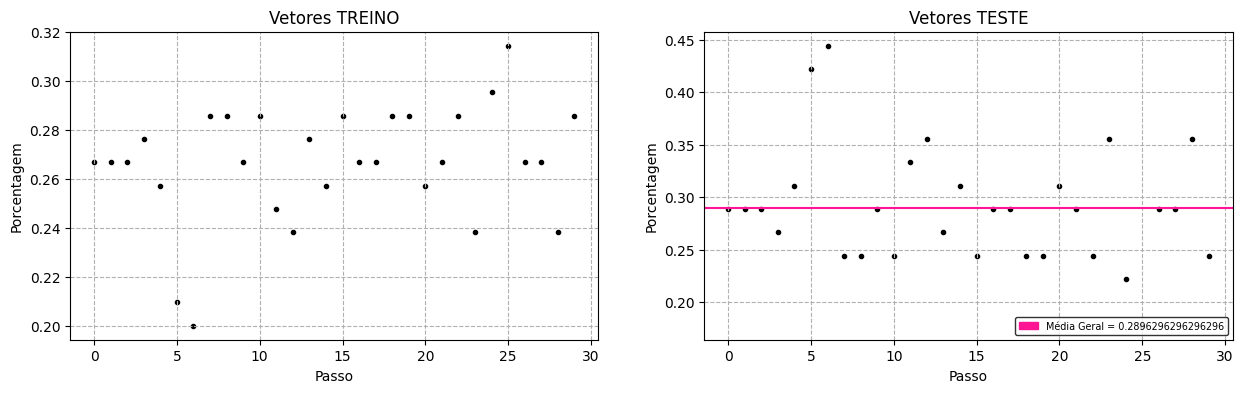

In [6]:
def vetores(start,stop): #Função para formar os vetores de treino e final
  #Mecanismo de Escolha Aleatória
  lista=[]
  for i in range(start,stop):
    lista.append(i) #Lista de índices
  lista=np.array(lista)

  reducao=np.sort(np.random.choice(lista,35,replace=False)) #Escolha aleatória de 35 índices

  vetores_treino=[]
  vetores_final=[]
  for i in range(35):
    vetores_treino.append(iris.data[int(reducao[i])])
    lista=lista[lista!=reducao[i]] #Filtro para array

  for i in range(15):
    vetores_final.append(iris.data[int(lista[i])])

  vetores_treino=np.array(vetores_treino)
  vetores_final=np.array(vetores_final)

  return vetores_treino,vetores_final,reducao

iris = datasets.load_iris()
normalizacao(0.7*np.pi,iris.data,peso_estatistico=False,normalizacao_pelo_maximo=True,normalizacao_vetorial_linha=False,normalizacao_vetorial_coluna=False)
w1,w2,w3=pesos_normalizados(iris.data)

media_geral=[]
fig,ax=plt.subplots(1,2,figsize=(15,4))
for m in range(30):
  start=0
  stop=50
  vetores_treino=[]
  vetores_final=[]
  indices=[]
  for k in range(3):
    a,b,reducao=vetores(start,stop)
    for i in range(len(a)):
      vetores_treino.append(a[i])
      indices.append(reducao[i])
    for i in range(len(b)):
      vetores_final.append(b[i])
    start+=50
    stop+=50

  vetores_treino=np.array(vetores_treino)
  vetores_final=np.array(vetores_final)

  Nin=0
  for i in range(len(vetores_treino)):
    escolha_sistema=classificador_nos_sistemas(vetores_treino[i],w1,w2,w3)
    if i<35:
      if escolha_sistema==1:
        Nin+=1
    if 35<=i and i<70:
      if escolha_sistema==2:
        Nin+=1
    if 70<=i and i<105:
      if escolha_sistema==3:
        Nin+=1

  percentual_treino=Nin/105
  ax[0].scatter(m,percentual_treino,color='k',marker='.')
  ax[0].set_xlabel('Passo')
  ax[0].set_ylabel('Porcentagem')
  ax[0].grid(ls='--')
  ax[0].title.set_text('Vetores TREINO')

  Nin=0
  for i in range(len(vetores_final)):
    escolha_sistema=classificador_nos_sistemas(vetores_final[i],w1,w2,w3)
    if i<15:
      if escolha_sistema==1:
        Nin+=1
    if 15<=i and i<30:
      if escolha_sistema==2:
        Nin+=1
    if 30<=i and i<45:
      if escolha_sistema==3:
        Nin+=1

  percentual=Nin/45
  media_geral.append(percentual)
  ax[1].scatter(m,percentual,color='k',marker='.')
  ax[1].set_xlabel('Passo')
  ax[1].set_ylabel('Porcentagem')
  ax[1].grid(ls='--')
  ax[1].title.set_text('Vetores TESTE')
media_geral=np.mean(np.array(media_geral))
ax[1].axhline(media_geral,color='deeppink')
mg=mpatches.Patch(color='deeppink',label=f'Média Geral = {media_geral}')
ax[1].legend(handles=[mg], loc='lower right',fontsize='x-small',edgecolor='black')
fig.savefig('duo.png')
plt.show()

$\cdot$ O classificador se mostra simétrico para o sinal dos valores de escala


$\cdot$ A matriz $\mathcal{I}$ não parece interferir significativamente na precisão do modelo, porém interfere na localização do ponto de máximo global

$\cdot\cdot$ A precisão no modelo com o peso estatistico parece ter aumentado

## Peso Estatístico

In [8]:
#@title fator_de_escala + Peso Estatístico

fator_de_escala=np.pi*np.linspace(0,30,100,endpoint=True) #O classifica

def vetores(start,stop): #Função para formar os vetores de treino e final
    #Mecanismo de Escolha Aleatória
    lista=[]
    for i in range(start,stop):
      lista.append(i) #Lista de índices
    lista=np.array(lista)

    reducao=np.sort(np.random.choice(lista,35,replace=False)) #Escolha aleatória de 35 índices

    vetores_treino=[]
    vetores_final=[]
    for i in range(35):
      vetores_treino.append(iris.data[int(reducao[i])])
      lista=lista[lista!=reducao[i]] #Filtro para array

    for i in range(15):
      vetores_final.append(iris.data[int(lista[i])])

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)

    return vetores_treino,vetores_final,reducao

media=[]
contador=0
for n in fator_de_escala:
  iris = datasets.load_iris()
  normalizacao(n,iris.data,peso_estatistico=True,normalizacao_pelo_maximo=False,normalizacao_vetorial_linha=False,normalizacao_vetorial_coluna=False)
  w1,w2,w3=pesos_normalizados(iris.data)



  media_geral=[]
  for m in range(20):
    start=0
    stop=50
    vetores_treino=[]
    vetores_final=[]
    indices=[]
    for k in range(3):
      a,b,reducao=vetores(start,stop)
      for i in range(len(a)):
        vetores_treino.append(a[i])
        indices.append(reducao[i])
      for i in range(len(b)):
        vetores_final.append(b[i])
      start+=50
      stop+=50

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)



    Nin=0
    for i in range(len(vetores_final)):
      escolha_sistema=classificador_nos_sistemas(vetores_final[i],w1,w2,w3)
      if i<15:
        if escolha_sistema==1:
          Nin+=1
      if 15<=i and i<30:
        if escolha_sistema==2:
          Nin+=1
      if 30<=i and i<45:
        if escolha_sistema==3:
          Nin+=1

    percentual=Nin/45
    media_geral.append(percentual)
  media_geral=np.mean(np.array(media_geral))
  media.append(media_geral)
  contador+=1

fig,ax=plt.subplots(1,1,figsize=(7,8.5))
print(pd.DataFrame(media,index=[f'Fator de Escala[{i}] = {fator_de_escala[i]}' for i in range(len(fator_de_escala))],columns=['Porcentagem']))
ax.scatter(fator_de_escala,media,color='k',marker='.')
"""ax.set_xlabel('Fator de Escala')
ax.set_ylabel('Media')"""
ax.grid(ls='--')
#plt.title('Vetores TESTE')
#media_total=np.mean(np.array(media))
#plt.axhline(media_total,color='deeppink')
"""k=np.argmax(media)
ax.scatter(fator_de_escala[k],media[k],color='deeppink',marker='*')
mg=mpatches.Patch(color='deeppink',label=f'(Fator de Escala,Maior % de acertos)\n              ({round(fator_de_escala[k]/np.pi,3)}$\pi$ , {round(media[k],4)})')
ax.legend(handles=[mg],bbox_to_anchor=(0.47, -0.1),loc='upper center',fontsize='x-small',edgecolor='black',ncol=2)
#plt.title(f'Intervalo Fator de Escala: [{fator_de_escala[0]},{fator_de_escala[-1]}]')
plt.title('Norm.: [0,1], peso(MÁX)=1 e peso(MÍN)=1')"""
plt.tight_layout()
fig.savefig('min-max.png')
plt.show()



<>:89: SyntaxWarning: invalid escape sequence '\p'
<>:89: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_13748\850789693.py:89: SyntaxWarning: invalid escape sequence '\p'
  mg=mpatches.Patch(color='deeppink',label=f'(Fator de Escala,Maior % de acertos)\n              ({round(fator_de_escala[k]/np.pi,3)}$\pi$ , {round(media[k],4)})')
C:\Users\pichau\AppData\Local\Temp\ipykernel_13748\850789693.py:89: SyntaxWarning: invalid escape sequence '\p'
  mg=mpatches.Patch(color='deeppink',label=f'(Fator de Escala,Maior % de acertos)\n              ({round(fator_de_escala[k]/np.pi,3)}$\pi$ , {round(media[k],4)})')


KeyboardInterrupt: 

$\cdot$ Máximo com a Identidade:

$\cdot$ Máximo sem a Identidade: $\approx$ 0.747*$\pi$

## Normalização pelo Máximo

<>:89: SyntaxWarning: invalid escape sequence '\p'
<>:89: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_10432\3349533167.py:89: SyntaxWarning: invalid escape sequence '\p'
  mg=mpatches.Patch(color='deeppink',label=f'(Fator de Escala,Maior % de acertos)\n              ({round(fator_de_escala[k]/np.pi,3)}$\pi$ , {round(media[k],4)})')


                                           Porcentagem
Fator de Escala[0] = 0.0                      0.333333
Fator de Escala[1] = 0.03157379551346526      0.333333
Fator de Escala[2] = 0.06314759102693052      0.333333
Fator de Escala[3] = 0.09472138654039577      0.333333
Fator de Escala[4] = 0.12629518205386103      0.333333
...                                                ...
Fator de Escala[195] = 6.1568901251257255     0.333333
Fator de Escala[196] = 6.188463920639191      0.333333
Fator de Escala[197] = 6.220037716152656      0.333333
Fator de Escala[198] = 6.251611511666121      0.333333
Fator de Escala[199] = 6.283185307179586      0.333333

[200 rows x 1 columns]


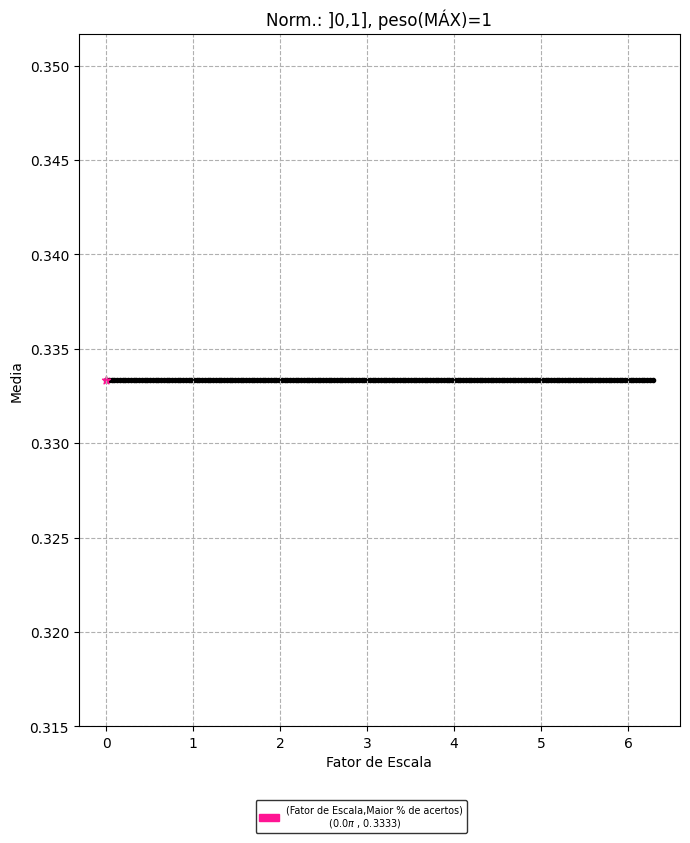

In [15]:
#@title fator_de_escala + Normalização pelo Máximo

fator_de_escala=np.pi*np.linspace(0,2,200,endpoint=True)

def vetores(start,stop): #Função para formar os vetores de treino e final
    #Mecanismo de Escolha Aleatória
    lista=[]
    for i in range(start,stop):
      lista.append(i) #Lista de índices
    lista=np.array(lista)

    reducao=np.sort(np.random.choice(lista,35,replace=False)) #Escolha aleatória de 35 índices

    vetores_treino=[]
    vetores_final=[]
    for i in range(35):
      vetores_treino.append(iris.data[int(reducao[i])])
      lista=lista[lista!=reducao[i]] #Filtro para array

    for i in range(15): #Loop para os vetores de teste
      vetores_final.append(iris.data[int(lista[i])])

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)

    return vetores_treino,vetores_final,reducao

media=[]
contador=0
for n in fator_de_escala:
  iris = datasets.load_iris()
  normalizacao(n,iris.data,peso_estatistico=False,normalizacao_pelo_maximo=True,normalizacao_vetorial_linha=False,normalizacao_vetorial_coluna=False)
  w1,w2,w3=pesos_normalizados(iris.data)



  media_geral=[]
  for m in range(20): #Loop para a média
    start=0
    stop=50
    vetores_treino=[]
    vetores_final=[]
    indices=[]
    for k in range(3):
      a,b,reducao=vetores(start,stop)
      for i in range(len(a)):
        vetores_treino.append(a[i])
        indices.append(reducao[i])
      for i in range(len(b)):
        vetores_final.append(b[i])
      start+=50
      stop+=50

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)



    Nin=0
    for i in range(len(vetores_final)):
      escolha_sistema=classificador_nos_sistemas(vetores_final[i],w1,w2,w3)
      if i<15:
        if escolha_sistema==1:
          Nin+=1
      if 15<=i and i<30:
        if escolha_sistema==2:
          Nin+=1
      if 30<=i and i<45:
        if escolha_sistema==3:
          Nin+=1

    percentual=Nin/45
    media_geral.append(percentual)
  media_geral=np.mean(np.array(media_geral))
  media.append(media_geral)
  contador+=1

fig,ax=plt.subplots(1,1,figsize=(7,8.5))
print(pd.DataFrame(media,index=[f'Fator de Escala[{i}] = {fator_de_escala[i]}' for i in range(len(fator_de_escala))],columns=['Porcentagem']))
ax.scatter(fator_de_escala,media,color='k',marker='.')
ax.set_xlabel('Fator de Escala')
ax.set_ylabel('Media')
ax.grid(ls='--')
#plt.title('Vetores TESTE')
#media_total=np.mean(np.array(media))
#plt.axhline(media_total,color='deeppink')
k=np.argmax(media)
ax.scatter(fator_de_escala[k],media[k],color='deeppink',marker='*')
mg=mpatches.Patch(color='deeppink',label=f'(Fator de Escala,Maior % de acertos)\n              ({round(fator_de_escala[k]/np.pi,3)}$\pi$ , {round(media[k],4)})')
ax.legend(handles=[mg],bbox_to_anchor=(0.47, -0.1),loc='upper center',fontsize='x-small',edgecolor='black',ncol=2)
#plt.title(f'Intervalo Fator de Escala: [{fator_de_escala[0]},{fator_de_escala[-1]}]')
plt.title('Norm.: ]0,1], peso(MÁX)=1')
plt.tight_layout()
fig.savefig('normalizacao_pelo_máximo.png')
plt.show()



$\cdot$ Máximo com a Identidade:

$\cdot$ Máximo sem a Identidade: $\approx$ 0.686*$\pi$

## Normalização pela linha

<>:89: SyntaxWarning: invalid escape sequence '\p'
<>:89: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_10432\4134437085.py:89: SyntaxWarning: invalid escape sequence '\p'
  mg=mpatches.Patch(color='deeppink',label=f'(Fator de Escala,Maior % de acertos)\n              ({round(fator_de_escala[k]/np.pi,3)}$\pi$ , {round(media[k],4)})')


                                           Porcentagem
Fator de Escala[0] = 0.0                      0.333333
Fator de Escala[1] = 0.5209676259721767       0.333333
Fator de Escala[2] = 1.0419352519443534       0.333333
Fator de Escala[3] = 1.5629028779165302       0.333333
Fator de Escala[4] = 2.083870503888707        0.333333
...                                                ...
Fator de Escala[195] = 101.58868706457446     0.333333
Fator de Escala[196] = 102.10965469054663     0.333333
Fator de Escala[197] = 102.63062231651881     0.333333
Fator de Escala[198] = 103.151589942491       0.333333
Fator de Escala[199] = 103.67255756846318     0.333333

[200 rows x 1 columns]


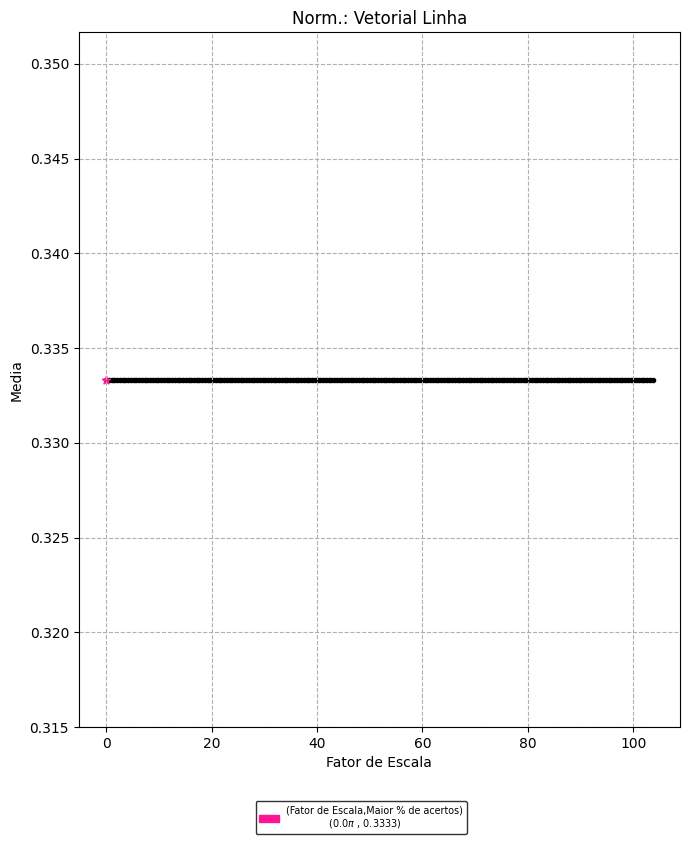

In [16]:
#@title fator_de_escala=np.pi + Normalização pela linha

fator_de_escala=np.pi*np.linspace(0,33,200,endpoint=True)

def vetores(start,stop): #Função para formar os vetores de treino e final
    #Mecanismo de Escolha Aleatória
    lista=[]
    for i in range(start,stop):
      lista.append(i) #Lista de índices
    lista=np.array(lista)

    reducao=np.sort(np.random.choice(lista,35,replace=False)) #Escolha aleatória de 35 índices

    vetores_treino=[]
    vetores_final=[]
    for i in range(35):
      vetores_treino.append(iris.data[int(reducao[i])])
      lista=lista[lista!=reducao[i]] #Filtro para array

    for i in range(15):
      vetores_final.append(iris.data[int(lista[i])])

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)

    return vetores_treino,vetores_final,reducao

media=[]
contador=0
for n in fator_de_escala:
  iris = datasets.load_iris()
  normalizacao(n,iris.data,peso_estatistico=False,normalizacao_pelo_maximo=False,normalizacao_vetorial_linha=True,normalizacao_vetorial_coluna=False)
  w1,w2,w3=pesos_normalizados(iris.data)



  media_geral=[]
  for m in range(20):
    start=0
    stop=50
    vetores_treino=[]
    vetores_final=[]
    indices=[]
    for k in range(3):
      a,b,reducao=vetores(start,stop)
      for i in range(len(a)):
        vetores_treino.append(a[i])
        indices.append(reducao[i])
      for i in range(len(b)):
        vetores_final.append(b[i])
      start+=50
      stop+=50

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)



    Nin=0
    for i in range(len(vetores_final)):
      escolha_sistema=classificador_nos_sistemas(vetores_final[i],w1,w2,w3)
      if i<15:
        if escolha_sistema==1:
          Nin+=1
      if 15<=i and i<30:
        if escolha_sistema==2:
          Nin+=1
      if 30<=i and i<45:
        if escolha_sistema==3:
          Nin+=1

    percentual=Nin/45
    media_geral.append(percentual)
  media_geral=np.mean(np.array(media_geral))
  media.append(media_geral)
  contador+=1

fig,ax=plt.subplots(1,1,figsize=(7,8.5))
print(pd.DataFrame(media,index=[f'Fator de Escala[{i}] = {fator_de_escala[i]}' for i in range(len(fator_de_escala))],columns=['Porcentagem']))
ax.scatter(fator_de_escala,media,color='k',marker='.')
ax.set_xlabel('Fator de Escala')
ax.set_ylabel('Media')
ax.grid(ls='--')
#plt.title('Vetores TESTE')
#media_total=np.mean(np.array(media))
#plt.axhline(media_total,color='deeppink')
k=np.argmax(media)
ax.scatter(fator_de_escala[k],media[k],color='deeppink',marker='*')
mg=mpatches.Patch(color='deeppink',label=f'(Fator de Escala,Maior % de acertos)\n              ({round(fator_de_escala[k]/np.pi,3)}$\pi$ , {round(media[k],4)})')
ax.legend(handles=[mg],bbox_to_anchor=(0.47, -0.1),loc='upper center',fontsize='x-small',edgecolor='black',ncol=2)
#plt.title(f'Intervalo Fator de Escala: [{fator_de_escala[0]},{fator_de_escala[-1]}]')
plt.title('Norm.: Vetorial Linha')
plt.tight_layout()
fig.savefig('normalizacao_vetorial_linha.jpg')
plt.show()



$\cdot$ Máximo com a Identidade:

$\cdot$ Máximo sem a Identidade: $\approx$ 0.747*$\pi$

## Normalização pela coluna

<>:89: SyntaxWarning: invalid escape sequence '\p'
<>:89: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pichau\AppData\Local\Temp\ipykernel_10432\3194784145.py:89: SyntaxWarning: invalid escape sequence '\p'
  mg=mpatches.Patch(color='deeppink',label=f'(Fator de Escala,Maior % de acertos)\n              ({round(fator_de_escala[k]/np.pi,3)}$\pi$ , {round(media[k],4)})')


                                           Porcentagem
Fator de Escala[0] = 0.0                      0.333333
Fator de Escala[1] = 0.5209676259721767       0.333333
Fator de Escala[2] = 1.0419352519443534       0.333333
Fator de Escala[3] = 1.5629028779165302       0.333333
Fator de Escala[4] = 2.083870503888707        0.333333
...                                                ...
Fator de Escala[195] = 101.58868706457446     0.333333
Fator de Escala[196] = 102.10965469054663     0.333333
Fator de Escala[197] = 102.63062231651881     0.333333
Fator de Escala[198] = 103.151589942491       0.333333
Fator de Escala[199] = 103.67255756846318     0.333333

[200 rows x 1 columns]


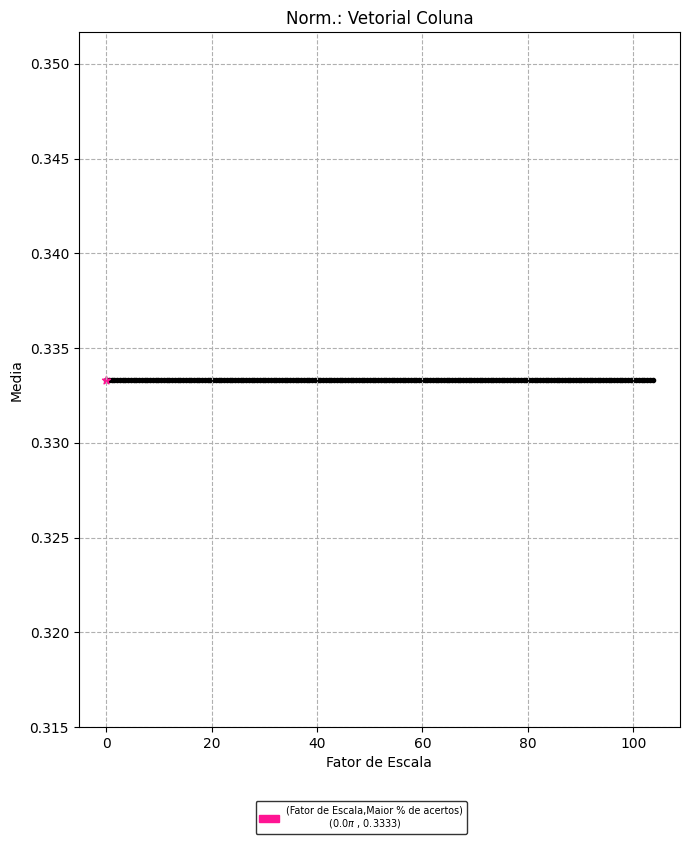

In [17]:
#@title fator_de_escala=np.pi + Normalização pela coluna

fator_de_escala=np.pi*np.linspace(0,33,200,endpoint=True)

def vetores(start,stop): #Função para formar os vetores de treino e final
    #Mecanismo de Escolha Aleatória
    lista=[]
    for i in range(start,stop):
      lista.append(i) #Lista de índices
    lista=np.array(lista)

    reducao=np.sort(np.random.choice(lista,35,replace=False)) #Escolha aleatória de 35 índices

    vetores_treino=[]
    vetores_final=[]
    for i in range(35):
      vetores_treino.append(iris.data[int(reducao[i])])
      lista=lista[lista!=reducao[i]] #Filtro para array

    for i in range(15):
      vetores_final.append(iris.data[int(lista[i])])

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)

    return vetores_treino,vetores_final,reducao

media=[]
contador=0
for n in fator_de_escala:
  iris = datasets.load_iris()
  normalizacao(n,iris.data,peso_estatistico=False,normalizacao_pelo_maximo=False,normalizacao_vetorial_linha=False,normalizacao_vetorial_coluna=True)
  w1,w2,w3=pesos_normalizados(iris.data)



  media_geral=[]
  for m in range(20):
    start=0
    stop=50
    vetores_treino=[]
    vetores_final=[]
    indices=[]
    for k in range(3):
      a,b,reducao=vetores(start,stop)
      for i in range(len(a)):
        vetores_treino.append(a[i])
        indices.append(reducao[i])
      for i in range(len(b)):
        vetores_final.append(b[i])
      start+=50
      stop+=50

    vetores_treino=np.array(vetores_treino)
    vetores_final=np.array(vetores_final)



    Nin=0
    for i in range(len(vetores_final)):
      escolha_sistema=classificador_nos_sistemas(vetores_final[i],w1,w2,w3)
      if i<15:
        if escolha_sistema==1:
          Nin+=1
      if 15<=i and i<30:
        if escolha_sistema==2:
          Nin+=1
      if 30<=i and i<45:
        if escolha_sistema==3:
          Nin+=1

    percentual=Nin/45
    media_geral.append(percentual)
  media_geral=np.mean(np.array(media_geral))
  media.append(media_geral)
  contador+=1

fig,ax=plt.subplots(1,1,figsize=(7,8.5))
print(pd.DataFrame(media,index=[f'Fator de Escala[{i}] = {fator_de_escala[i]}' for i in range(len(fator_de_escala))],columns=['Porcentagem']))
ax.scatter(fator_de_escala,media,color='k',marker='.')
ax.set_xlabel('Fator de Escala')
ax.set_ylabel('Media')
ax.grid(ls='--')
#plt.title('Vetores TESTE')
#media_total=np.mean(np.array(media))
#plt.axhline(media_total,color='deeppink')
k=np.argmax(media)
ax.scatter(fator_de_escala[k],media[k],color='deeppink',marker='*')
mg=mpatches.Patch(color='deeppink',label=f'(Fator de Escala,Maior % de acertos)\n              ({round(fator_de_escala[k]/np.pi,3)}$\pi$ , {round(media[k],4)})')
ax.legend(handles=[mg],bbox_to_anchor=(0.47, -0.1),loc='upper center',fontsize='x-small',edgecolor='black',ncol=2)
#plt.title(f'Intervalo Fator de Escala: [{fator_de_escala[0]},{fator_de_escala[-1]}]')
plt.title('Norm.: Vetorial Coluna')
plt.tight_layout()
fig.savefig('normalizacao_vetorial_coluna.jpg')
plt.show()

